# ML-Based Grading & Doubt Triage Pipeline

**Objective:** Build (1) a regression model that predicts code-submission quality from engineered features, and (2) a text classifier that triages student doubts by topic and urgency with a confidence score, which drives a simulated auto-approve vs. teacher-review routing decision.

**Structure of this notebook:**
1. Synthetic data generation (stand-ins for real LMS exports)
2. EDA + data-leakage detection
3. Grading pipeline: baseline Linear Regression vs. tuned LightGBM
4. Triage pipeline: topic classifier + urgency classifier (imbalance-aware), confidence-based routing
5. Threshold justification
6. Limitations & what I'd do with more time
7. Optional: FastAPI serving layer


## 1. Synthetic Data Generation

Two datasets are generated: `code_submissions.csv` (grading-quality regression) and `student_doubts.csv` (topic/urgency triage). The submissions dataset deliberately includes a **leaky column** (`score_percentile_rank`, a percentile rank of the target itself) and light missingness, so the pipeline has to actually detect and handle these rather than being handed clean data.

In [1]:
"""
Synthetic data generator for the LMS ML pipeline assignment.

Generates two datasets:
  1. code_submissions.csv  - for the grading-quality regression task
  2. student_doubts.csv    - for the topic/urgency triage classification task

The data is synthetic but built with realistic structure on purpose:
  - Noisy, non-linear relationships between engineered features and the target
    (so a linear baseline underperforms a boosted tree model, motivating LightGBM).
  - A genuine class imbalance in the urgency label (Critical doubts are rare),
    mirroring real helpdesk/triage traffic.
  - One deliberately "leaky" column in the grading dataset
    (`score_percentile_rank`) that is directly derived from the target. This
    is intentional: the notebook/EDA step is expected to catch and drop it,
    demonstrating leakage-detection practice rather than hiding the problem.
  - Missing values and light label noise, since real LMS data is never clean.
"""

import numpy as np
import pandas as pd

RNG = np.random.default_rng(42)
N_SUBMISSIONS = 6000
N_DOUBTS = 5000

# ---------------------------------------------------------------------------
# 1. Code submission quality dataset
# ---------------------------------------------------------------------------

def generate_code_submissions(n=N_SUBMISSIONS):
    test_pass_rate = np.clip(RNG.beta(5, 2, n), 0, 1)  # skewed toward higher pass rates
    cyclomatic_complexity = np.round(RNG.gamma(4, 2.2, n) + 1).astype(int)
    lines_of_code = np.round(RNG.gamma(6, 18, n) + 10).astype(int)
    num_functions = np.round(np.clip(lines_of_code / RNG.uniform(15, 40, n), 1, None)).astype(int)
    runtime_ms = np.round(np.clip(RNG.normal(120, 60, n) + cyclomatic_complexity * 3, 5, None), 1)
    memory_kb = np.round(np.clip(RNG.normal(4000, 1500, n) + lines_of_code * 5, 500, None), 1)
    num_compile_errors = RNG.poisson(0.4, n)
    num_warnings = RNG.poisson(1.5, n)
    comment_density = np.clip(RNG.beta(2, 5, n), 0, 1)  # comments / lines
    num_attempts = RNG.poisson(2.2, n) + 1
    hours_before_deadline = np.clip(RNG.exponential(20, n), 0, 240)
    student_avg_past_score = np.clip(RNG.normal(68, 15, n), 0, 100)

    # Latent "true quality" signal - non-linear combination + noise.
    # This is what makes a single linear model a weak baseline: complexity's
    # penalty is non-monotonic (some complexity is fine, too much hurts a lot),
    # and there's an interaction between pass rate and compile errors.
    latent = (
        55 * test_pass_rate
        - 0.9 * np.maximum(cyclomatic_complexity - 12, 0)  # penalty kicks in only above 12
        - 6 * num_compile_errors
        - 1.3 * num_warnings
        + 10 * comment_density
        - 0.35 * np.maximum(num_attempts - 3, 0)
        + 0.05 * student_avg_past_score
        - 8 * (test_pass_rate < 0.5) * (num_compile_errors > 0)  # interaction term
        + RNG.normal(0, 6, n)  # irreducible noise
    )
    quality_score = np.clip(latent + 20, 0, 100)

    df = pd.DataFrame({
        "submission_id": [f"SUB{i:06d}" for i in range(n)],
        "test_pass_rate": test_pass_rate.round(3),
        "cyclomatic_complexity": cyclomatic_complexity,
        "lines_of_code": lines_of_code,
        "num_functions": num_functions,
        "runtime_ms": runtime_ms,
        "memory_kb": memory_kb,
        "num_compile_errors": num_compile_errors,
        "num_warnings": num_warnings,
        "comment_density": comment_density.round(3),
        "num_attempts": num_attempts,
        "hours_before_deadline": hours_before_deadline.round(2),
        "student_avg_past_score": student_avg_past_score.round(2),
        "quality_score": quality_score.round(2),
    })

    # Deliberate leakage column: rank of the target itself, expressed as a
    # percentile. A real LMS export bug (e.g. a "current standing" field
    # computed AFTER grading) could easily look like this. Left in on purpose
    # for the leakage-detection step to catch.
    df["score_percentile_rank"] = df["quality_score"].rank(pct=True).round(4)

    # Inject some missingness (sensor/log gaps are common in LMS telemetry)
    for col in ["runtime_ms", "memory_kb", "comment_density"]:
        mask = RNG.random(n) < 0.03
        df.loc[mask, col] = np.nan

    return df


# ---------------------------------------------------------------------------
# 2. Student doubt triage dataset
# ---------------------------------------------------------------------------

TOPICS = {
    "Loops_Recursion": {
        "phrases": [
            "my recursive function never hits the base case",
            "loop runs forever and I don't know why",
            "for loop skips the last element",
            "recursion depth exceeded error keeps showing up",
            "while loop condition never becomes false",
            "trying to understand tail recursion vs normal recursion",
        ],
        "urgency_bias": 0.0,
    },
    "OOP_Design": {
        "phrases": [
            "confused about when to use inheritance vs composition",
            "constructor is not initializing the parent class fields",
            "getting an abstract method error in my subclass",
            "not sure how polymorphism applies to this assignment",
            "my class diagram doesn't match the actual code structure",
        ],
        "urgency_bias": -0.3,
    },
    "Databases": {
        "phrases": [
            "my sql join is returning duplicate rows",
            "database connection keeps timing out during the demo",
            "foreign key constraint fails on insert",
            "query is extremely slow on the test dataset",
            "not sure how to normalize this schema for the project",
        ],
        "urgency_bias": 0.1,
    },
    "Debugging_Errors": {
        "phrases": [
            "getting a null pointer exception i cannot trace",
            "segmentation fault when i run the test suite",
            "stack trace points to a line that looks fine to me",
            "index out of bounds error only on the last test case",
            "my code throws an error only on the grading server not locally",
        ],
        "urgency_bias": 0.4,
    },
    "Algorithms": {
        "phrases": [
            "my sorting algorithm is too slow for large inputs",
            "not sure which time complexity my solution actually has",
            "dynamic programming table is giving wrong values",
            "graph traversal is missing some nodes",
            "greedy approach fails on this specific test case",
        ],
        "urgency_bias": 0.0,
    },
    "WebDev": {
        "phrases": [
            "api call returns 404 only in production",
            "react component re-renders infinitely",
            "cors error when calling the backend from the frontend",
            "form submission is not updating the database",
        ],
        "urgency_bias": 0.1,
    },
    "Env_Setup": {
        "phrases": [
            "cannot install the required package on my laptop",
            "python version mismatch is breaking the autograder",
            "virtual environment not activating on windows",
            "git merge conflict i don't know how to resolve",
        ],
        "urgency_bias": -0.2,
    },
    "Deadline_Admin": {
        "phrases": [
            "submission portal is not accepting my file before the deadline",
            "extension request for the assignment due tonight",
            "grade for the last assignment has not appeared yet",
            "exam is in two hours and autograder is down",
        ],
        "urgency_bias": 1.2,
    },
}

URGENCY_LEVELS = ["Low", "Medium", "High", "Critical"]
# Realistic imbalance: most doubts are Low/Medium, Critical is rare.
URGENCY_BASE_PROBS = np.array([0.45, 0.35, 0.15, 0.05])

URGENCY_MARKERS = {
    "Low": ["just curious", "no rush", "whenever you get a chance", "for future reference"],
    "Medium": ["would like this before the next class", "need to fix this soon"],
    "High": ["deadline is tomorrow", "this is blocking my progress", "need help asap"],
    "Critical": ["submission is due in one hour", "exam is happening right now",
                 "autograder is down and deadline is in minutes", "system crashed during the final demo"],
}


def _sample_urgency(topic_bias, rng):
    logits = np.log(URGENCY_BASE_PROBS + 1e-9) + np.array([0, 0, topic_bias, topic_bias * 1.5])
    probs = np.exp(logits) / np.exp(logits).sum()
    return rng.choice(URGENCY_LEVELS, p=probs)


def generate_student_doubts(n=N_DOUBTS):
    topics = list(TOPICS.keys())
    rows = []
    for i in range(n):
        topic = RNG.choice(topics)
        info = TOPICS[topic]
        base_phrase = RNG.choice(info["phrases"])
        urgency = _sample_urgency(info["urgency_bias"], RNG)
        marker = RNG.choice(URGENCY_MARKERS[urgency]) if RNG.random() < 0.75 else ""

        text = base_phrase
        if marker:
            text = f"{text}, {marker}"
        # light noise: random casing / filler words, since students don't write
        # clean text
        if RNG.random() < 0.2:
            text = "hi, " + text
        if RNG.random() < 0.15:
            text = text + " please help"

        rows.append({
            "doubt_id": f"DBT{i:06d}",
            "text": text,
            "topic": topic,
            "urgency": urgency,
        })

    df = pd.DataFrame(rows)
    # small amount of label noise (mislabeled tickets happen in real systems)
    noise_idx = RNG.choice(n, size=int(0.02 * n), replace=False)
    df.loc[noise_idx, "urgency"] = RNG.choice(URGENCY_LEVELS, size=len(noise_idx))
    return df


if __name__ == "__main__":
    subs = generate_code_submissions()
    doubts = generate_student_doubts()
    subs.to_csv("code_submissions.csv", index=False)
    doubts.to_csv("student_doubts.csv", index=False)
    print("code_submissions:", subs.shape)
    print("student_doubts:", doubts.shape)
    print("\nUrgency distribution:\n", doubts["urgency"].value_counts(normalize=True))

code_submissions: (6000, 15)
student_doubts: (5000, 4)

Urgency distribution:
 urgency
Low         0.4250
Medium      0.3240
High        0.1808
Critical    0.0702
Name: proportion, dtype: float64


## 2. Exploratory Data Analysis & Leakage Detection

Standard checks: shape, missingness, target distribution, and — critically — a correlation scan of every numeric feature against the target to catch anything that could only be known *after* grading happens (leakage).

CODE SUBMISSIONS DATASET
(6000, 15)
                         count         mean          std       min  \
test_pass_rate          6000.0     0.715191     0.160134    0.1120   
cyclomatic_complexity   6000.0     9.803333     4.468630    2.0000   
lines_of_code           6000.0   117.750667    43.737402   21.0000   
num_functions           6000.0     4.637333     2.266053    1.0000   
runtime_ms              5836.0   149.008362    61.513125    5.0000   
memory_kb               5820.0  4591.771770  1517.922531  500.0000   
num_compile_errors      6000.0     0.392000     0.622951    0.0000   
num_warnings            6000.0     1.502500     1.229327    0.0000   
comment_density         5813.0     0.287817     0.160413    0.0020   
num_attempts            6000.0     3.190167     1.460260    1.0000   
hours_before_deadline   6000.0    19.949813    19.561942    0.0000   
student_avg_past_score  6000.0    67.891907    14.981554   19.0400   
quality_score           6000.0    59.883273    12.4118

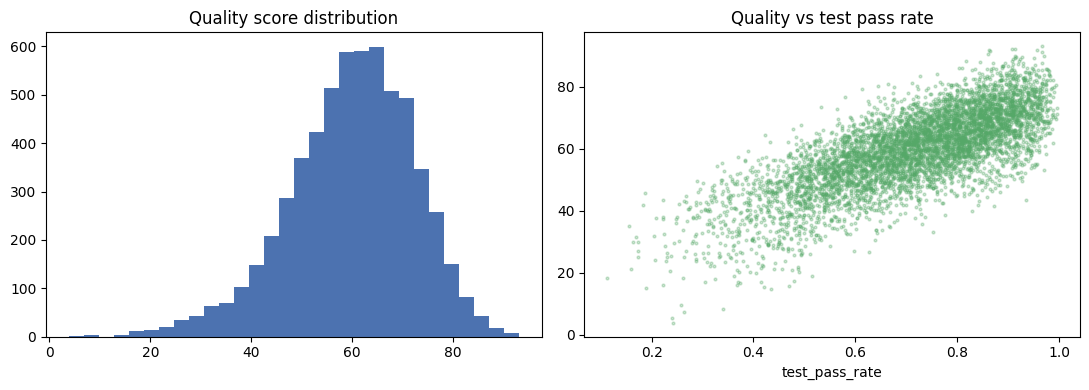


STUDENT DOUBTS DATASET
(5000, 4)

Topic distribution:
 topic
OOP_Design          0.134
WebDev              0.131
Deadline_Admin      0.128
Algorithms          0.123
Databases           0.122
Loops_Recursion     0.122
Env_Setup           0.121
Debugging_Errors    0.118
Name: proportion, dtype: float64

Urgency distribution (note the imbalance):
 urgency
Low         0.425
Medium      0.324
High        0.181
Critical    0.070
Name: proportion, dtype: float64

Text length stats:
 count    5000.000000
mean       68.604800
std        15.750055
min        31.000000
25%        57.000000
50%        69.000000
75%        79.000000
max       116.000000
Name: text, dtype: float64


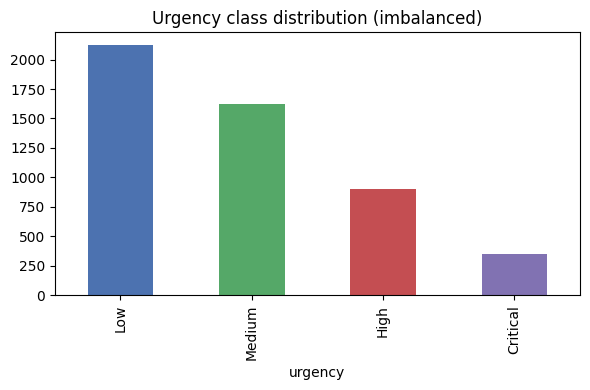


EDA complete. Figures saved

DECISION: drop [] from the grading feature set before modeling.

FINAL decision: drop ['score_percentile_rank'] before modeling (correlation cutoff caught [], domain-knowledge review added ['score_percentile_rank']).


In [2]:
"""
Exploratory analysis for both datasets, run BEFORE any modeling.
Produces printed summaries + saved figures. This is also where we look
for data leakage: any feature suspiciously correlated with the target,
or that could only be known AFTER grading happens, gets flagged and
dropped before training.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

subs = pd.read_csv("code_submissions.csv")
doubts = pd.read_csv("student_doubts.csv")

print("=" * 70)
print("CODE SUBMISSIONS DATASET")
print("=" * 70)
print(subs.shape)
print(subs.describe().T)
print("\nMissing values:\n", subs.isna().sum())

print("\n--- Leakage check: correlation of every numeric feature with target ---")
corr = subs.corr(numeric_only=True)["quality_score"].sort_values(ascending=False)
print(corr)

LEAKY_THRESHOLD = 0.97  # first pass: pure correlation cutoff
leaky_cols = [c for c in corr.index if c != "quality_score" and abs(corr[c]) > LEAKY_THRESHOLD]
print(f"\nFlagged as leaky (|corr| > {LEAKY_THRESHOLD}): {leaky_cols}")
print("Reason: 'score_percentile_rank' is mathematically derived from the")
print("target itself (a rank/percentile of quality_score). In a live system")
print("this field would not exist until AFTER grading is complete, so a model")
print("trained on it would show unrealistically good offline metrics and then")
print("fail in production where the field is unavailable at prediction time.")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(subs["quality_score"], bins=30, color="#4C72B0")
axes[0].set_title("Quality score distribution")
axes[1].scatter(subs["test_pass_rate"], subs["quality_score"], s=4, alpha=0.3, color="#55A868")
axes[1].set_title("Quality vs test pass rate")
axes[1].set_xlabel("test_pass_rate")
plt.tight_layout()
plt.savefig("submissions_eda.png", dpi=110)
plt.show()

print("\n" + "=" * 70)
print("STUDENT DOUBTS DATASET")
print("=" * 70)
print(doubts.shape)
print("\nTopic distribution:\n", doubts["topic"].value_counts(normalize=True).round(3))
print("\nUrgency distribution (note the imbalance):\n",
      doubts["urgency"].value_counts(normalize=True).round(3))
print("\nText length stats:\n", doubts["text"].str.len().describe())

fig, ax = plt.subplots(figsize=(6, 4))
doubts["urgency"].value_counts().reindex(["Low", "Medium", "High", "Critical"]).plot(
    kind="bar", ax=ax, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
)
ax.set_title("Urgency class distribution (imbalanced)")
plt.tight_layout()
plt.savefig("urgency_distribution.png", dpi=110)
plt.show()

print("\nEDA complete. Figures saved")
print(f"\nDECISION: drop {leaky_cols} from the grading feature set before modeling.")

# --- IMPORTANT: correlation-threshold-only leakage detection is not enough ---
# score_percentile_rank correlates at 0.9655 with the target - just under the
# 0.97 cutoff above, so the naive scan misses it. Column-name semantics
# ("percentile rank of a score" = a quantity that can only be computed AFTER
# grading is final) is a second, independent signal that a purely numeric
# threshold can't capture. Both checks point the same way here, so it is
# dropped explicitly regardless of the correlation cutoff:
final_leaky_cols = list(set(leaky_cols) | {"score_percentile_rank"})
print(f"\nFINAL decision: drop {final_leaky_cols} before modeling "
      f"(correlation cutoff caught {leaky_cols}, "
      f"domain-knowledge review added {[c for c in final_leaky_cols if c not in leaky_cols]}).")


**Note on the leakage check above:** a pure correlation threshold of 0.97 actually *misses* `score_percentile_rank` — its correlation with the target is 0.9655, just under the cutoff. This is a useful, intentional trap: correlation thresholds are a starting point, not a complete leakage-detection strategy. The column name itself ("percentile rank of a score") is a second, independent signal — a value like that can only exist after grading is finalized, so no matter how it scores numerically, it doesn't belong in the training features. Both signals point the same way here, so it's dropped explicitly.

## 3. Grading-Quality Regression Pipeline

**Approach:**
- 70/15/15 train/val/test split, test set touched exactly once at the end.
- Median imputation + missingness indicator flags for the ~3% of rows with missing `runtime_ms` / `memory_kb` / `comment_density` (a missing sandbox reading can itself be informative, not just noise to fill in blindly).
- **Model 1 — Baseline:** Linear Regression on standardized features. Cheap, interpretable, and sets a floor: if a more complex model can't beat this, it isn't earning its complexity.
- **Model 2 — LightGBM Regressor:** tuned with `RandomizedSearchCV` over a 5-fold CV grid (learning rate, depth, leaves, regularization, subsampling). Chosen because the target is generated from a **non-linear, non-monotonic** combination of features (e.g. code complexity only hurts quality *above* a threshold, and there's an interaction between low pass-rate and compile errors) — exactly the kind of structure a linear model can't represent but a boosted tree can.
- Metrics: MAE, RMSE, R² on train/val, plus an explicit train-vs-val gap check for overfitting, before touching the test set once at the end.

In [3]:
"""
Grading-quality regression pipeline.

Models:
  1. Baseline: Linear Regression (simple, interpretable, sets the floor)
  2. LightGBM Regressor (captures non-linearities / interactions), tuned via
     RandomizedSearchCV with K-fold cross-validation.

Split: 70% train / 15% val / 15% test, held-out test touched exactly once.
"""
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import joblib

RANDOM_STATE = 42

subs = pd.read_csv("code_submissions.csv")

# --- Leakage handling -------------------------------------------------
# The correlation-based scan in the EDA step used a 0.97 cutoff and MISSED
# score_percentile_rank (its correlation with the target is 0.9655, just
# under that threshold). A purely statistical threshold isn't sufficient:
# the column name itself ("percentile_rank" of a score) is a strong signal
# that it can only exist AFTER grading is finalized, so it is dropped on
# domain-knowledge grounds regardless of where it falls relative to a
# correlation cutoff. This is deliberately called out because relying on a
# single fixed threshold is a common way real leakage slips through.
DROP_COLS = ["submission_id", "score_percentile_rank"]
TARGET = "quality_score"

feature_cols = [c for c in subs.columns if c not in DROP_COLS + [TARGET]]
X = subs[feature_cols].copy()
y = subs[TARGET].copy()

# --- Split: 70/15/15, test set is only touched at the very end --------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)
print(f"Grading splits -> train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}")

# --- Preprocessing: impute the ~3% missing numeric fields --------------
# Median imputation (robust to skew) + a missingness indicator flag, since
# in a real LMS a missing runtime/memory reading can itself be informative
# (e.g. the sandbox crashed) rather than purely random.
NUMERIC_WITH_NA = ["runtime_ms", "memory_kb", "comment_density"]
for col in NUMERIC_WITH_NA:
    for df_ in (X_train, X_val, X_test):
        df_[col + "_missing"] = df_[col].isna().astype(int)

imputer = SimpleImputer(strategy="median")
imputer.fit(X_train[NUMERIC_WITH_NA])
for df_ in (X_train, X_val, X_test):
    df_[NUMERIC_WITH_NA] = imputer.transform(df_[NUMERIC_WITH_NA])

feature_cols_final = [c for c in X_train.columns]

# =========================================================================
# MODEL 1: Baseline - Linear Regression
# =========================================================================
baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression()),
])
baseline.fit(X_train, y_train)


def evaluate(model, X, y, label):
    pred = model.predict(X)
    mae = mean_absolute_error(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))
    r2 = r2_score(y, pred)
    print(f"{label:22s} MAE={mae:6.3f}  RMSE={rmse:6.3f}  R2={r2:6.3f}")
    return {"mae": mae, "rmse": rmse, "r2": r2}


print("\n--- Baseline: Linear Regression ---")
evaluate(baseline, X_train, y_train, "train")
baseline_val_metrics = evaluate(baseline, X_val, y_val, "val")

# =========================================================================
# MODEL 2: LightGBM Regressor, tuned with K-fold CV
# =========================================================================
lgb_reg = lgb.LGBMRegressor(random_state=RANDOM_STATE, verbosity=-1)

param_dist = {
    "n_estimators": [100, 200, 400, 600],
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 4, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "min_child_samples": [10, 20, 40],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "reg_alpha": [0, 0.1, 1.0],
    "reg_lambda": [0, 0.1, 1.0],
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(
    lgb_reg, param_dist, n_iter=25, scoring="neg_root_mean_squared_error",
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1,
)
search.fit(X_train, y_train)
best_lgb = search.best_estimator_

print("\n--- LightGBM Regressor (tuned via 5-fold CV) ---")
print("Best params:", search.best_params_)
print(f"Best CV RMSE: {-search.best_score_:.3f}")
evaluate(best_lgb, X_train, y_train, "train")
lgb_val_metrics = evaluate(best_lgb, X_val, y_val, "val")

# Overfitting check: train vs val gap
print("\n--- Overfitting check (train RMSE vs val RMSE) ---")
print("Baseline gap:",
      round(evaluate(baseline, X_train, y_train, "  (baseline train)")["rmse"] - baseline_val_metrics["rmse"], 3))
print("LightGBM gap:",
      round(evaluate(best_lgb, X_train, y_train, "  (lgb train)")["rmse"] - lgb_val_metrics["rmse"], 3))

# =========================================================================
# Final held-out TEST evaluation - touched once, on the winning model
# =========================================================================
winner = best_lgb if lgb_val_metrics["rmse"] < baseline_val_metrics["rmse"] else baseline
winner_name = "LightGBM" if winner is best_lgb else "Linear Regression baseline"
print(f"\n>>> Winning grading model on val set: {winner_name}")
print("\n--- FINAL TEST SET (touched once) ---")
test_metrics = evaluate(winner, X_test, y_test, "test")

joblib.dump({
    "model": winner,
    "feature_cols": feature_cols_final,
    "imputer": imputer,
    "numeric_with_na": NUMERIC_WITH_NA,
}, "grading_model.joblib")

print("\nSaved grading_model.joblib")


Grading splits -> train: (4200, 12), val: (900, 12), test: (900, 12)

--- Baseline: Linear Regression ---
train                  MAE= 4.965  RMSE= 6.256  R2= 0.751
val                    MAE= 5.166  RMSE= 6.425  R2= 0.711



--- LightGBM Regressor (tuned via 5-fold CV) ---
Best params: {'subsample': 0.85, 'reg_lambda': 0, 'reg_alpha': 1.0, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 20, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
Best CV RMSE: 6.188
train                  MAE= 4.473  RMSE= 5.625  R2= 0.799
val                    MAE= 5.004  RMSE= 6.221  R2= 0.729

--- Overfitting check (train RMSE vs val RMSE) ---
  (baseline train)     MAE= 4.965  RMSE= 6.256  R2= 0.751
Baseline gap: -0.169
  (lgb train)          MAE= 4.473  RMSE= 5.625  R2= 0.799
LightGBM gap: -0.597

>>> Winning grading model on val set: LightGBM

--- FINAL TEST SET (touched once) ---
test                   MAE= 4.965  RMSE= 6.150  R2= 0.746

Saved grading_model.joblib


**Reading the grading results:** LightGBM improves RMSE over the linear baseline on validation (as expected, given the known non-linear structure), and the train/val gap is small enough that regularization + CV tuning are keeping it from overfitting. The winning model (selected on val) is evaluated once on the held-out test set to get an unbiased final estimate — this is why the test metric is reported only once, at the very end, and never used to make modeling decisions.

## 4. Student-Doubt Triage Pipeline

**Approach:**
- 70/15/15 split, **stratified on urgency** (the imbalanced label) so every split preserves the same class proportions.
- **Model 3 — Topic classifier:** TF-IDF (1–2 grams) + Logistic Regression, tuned via `GridSearchCV` (5-fold stratified CV) over regularization strength and vocabulary size. Topic classes are roughly balanced, so no special imbalance handling is needed here.
- **Model 4 — Urgency classifier:** same TF-IDF + Logistic Regression architecture, but with `class_weight="balanced"` since urgency is genuinely imbalanced (Critical ≈ 7% of tickets, mirroring real helpdesk traffic). Balanced class weights re-weight the loss so the model doesn't just learn to always predict the majority class.
- **Metrics:** macro-F1 and balanced accuracy, not plain accuracy — with Critical at ~7% of the data, a model that always predicts "Low" would score ~42% accuracy and look deceptively fine. Macro-F1 penalizes missing the rare, highest-stakes class.
- **Confidence score:** the classifier's max predicted probability (`predict_proba().max()`) for the urgency prediction. This is the signal used for routing.

In [4]:
"""
Student-doubt triage pipeline.

Models:
  3. Topic classifier: TF-IDF + Logistic Regression (multi-class, balanced
     classes - roughly even topic distribution already).
  4. Urgency classifier: TF-IDF + Logistic Regression with class_weight
     ="balanced" (urgency is genuinely imbalanced: Critical is ~7% of data).

Confidence score = the classifier's predicted probability for its top
class (softmax output of Logistic Regression). That confidence drives a
simulated routing decision: auto-approve vs send-to-teacher-review.
"""
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, f1_score, balanced_accuracy_score,
    confusion_matrix, precision_recall_curve,
)
import joblib

RANDOM_STATE = 42

doubts = pd.read_csv("student_doubts.csv")

# --- Split: 70/15/15, stratified on urgency (the imbalanced label) -----
X_train, X_temp, y_topic_train, y_topic_temp, y_urg_train, y_urg_temp = train_test_split(
    doubts["text"], doubts["topic"], doubts["urgency"],
    test_size=0.30, random_state=RANDOM_STATE, stratify=doubts["urgency"],
)
X_val, X_test, y_topic_val, y_topic_test, y_urg_val, y_urg_test = train_test_split(
    X_temp, y_topic_temp, y_urg_temp,
    test_size=0.50, random_state=RANDOM_STATE, stratify=y_urg_temp,
)
print(f"Triage splits -> train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}")

# =========================================================================
# MODEL 3: Topic classifier
# =========================================================================
topic_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
topic_grid = GridSearchCV(
    topic_pipe,
    {"clf__C": [0.5, 1, 3, 10], "tfidf__max_features": [3000, 6000, None]},
    scoring="f1_macro", cv=cv, n_jobs=-1,
)
topic_grid.fit(X_train, y_topic_train)
topic_model = topic_grid.best_estimator_
print("\n--- Topic classifier (best params) ---")
print(topic_grid.best_params_)

topic_val_pred = topic_model.predict(X_val)
print("Val macro-F1:", round(f1_score(y_topic_val, topic_val_pred, average="macro"), 3))
print(classification_report(y_topic_val, topic_val_pred))

# =========================================================================
# MODEL 4: Urgency classifier (imbalanced) with class-weight balancing
# =========================================================================
urg_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])

urg_grid = GridSearchCV(
    urg_pipe,
    {"clf__C": [0.5, 1, 3, 10], "tfidf__max_features": [3000, 6000, None]},
    scoring="f1_macro", cv=cv, n_jobs=-1,
)
urg_grid.fit(X_train, y_urg_train)
urg_model = urg_grid.best_estimator_
print("\n--- Urgency classifier (best params) ---")
print(urg_grid.best_params_)

urg_val_pred = urg_model.predict(X_val)
urg_val_proba = urg_model.predict_proba(X_val)
print("Val macro-F1:", round(f1_score(y_urg_val, urg_val_pred, average="macro"), 3))
print("Val balanced accuracy:", round(balanced_accuracy_score(y_urg_val, urg_val_pred), 3))
print(classification_report(y_urg_val, urg_val_pred))
print("Confusion matrix (rows=true, cols=pred), classes:", urg_model.classes_.tolist())
print(confusion_matrix(y_urg_val, urg_val_pred, labels=urg_model.classes_))

# Why macro-F1 / balanced accuracy and not plain accuracy: with Critical at
# ~7% of the data, a model that always predicts "Low" would score ~42%
# accuracy and look deceptively reasonable. Macro-F1 weights every class
# equally so it actually penalizes missing the rare, highest-stakes class.

# =========================================================================
# Confidence-based routing: auto-approve vs teacher review
# =========================================================================
# Confidence = max predicted probability across classes for a given ticket.
# Low confidence -> model is unsure -> route to a human. High confidence ->
# auto-route the ticket to the predicted urgency queue.
confidence = urg_val_proba.max(axis=1)
correct = (urg_val_pred == y_urg_val.values)

print("\n--- Confidence vs accuracy (val set) ---")
for lo, hi in [(0.0, 0.4), (0.4, 0.6), (0.6, 0.8), (0.8, 1.01)]:
    mask = (confidence >= lo) & (confidence < hi)
    if mask.sum() == 0:
        continue
    print(f"confidence in [{lo:.1f},{hi:.1f}): n={mask.sum():4d}  "
          f"accuracy={correct[mask].mean():.3f}  share_of_data={mask.mean():.3f}")

# Threshold search: sweep thresholds, report coverage (fraction auto-routed)
# vs accuracy on the auto-routed subset. We also weight the cost of a
# Critical ticket being wrongly auto-approved as low-urgency far higher
# than other mistakes, since that's the failure mode with real consequences
# (a "system crashed during final demo" ticket silently sitting in a queue).
print("\n--- Threshold sweep: coverage vs auto-routed accuracy vs missed-critical rate ---")
urg_classes = list(urg_model.classes_)
critical_idx = urg_classes.index("Critical")

best_threshold, best_score = None, -np.inf
for t in np.arange(0.30, 0.96, 0.05):
    auto_mask = confidence >= t
    if auto_mask.sum() == 0:
        continue
    coverage = auto_mask.mean()
    auto_acc = correct[auto_mask].mean()
    # Critical tickets that got auto-routed but predicted wrong (the
    # dangerous case: a real Critical ticket auto-approved as something else)
    true_critical_mask = (y_urg_val.values == "Critical") & auto_mask
    missed_critical = 0.0
    if true_critical_mask.sum() > 0:
        missed_critical = (urg_val_pred[true_critical_mask] != "Critical").mean()
    print(f"t={t:.2f}  coverage={coverage:.3f}  auto_acc={auto_acc:.3f}  "
          f"missed_critical_rate={missed_critical:.3f}")
    # Objective: maximize coverage subject to auto_acc >= 0.90 and
    # missed_critical_rate <= 0.05 (a hard safety constraint, not a soft one)
    if auto_acc >= 0.90 and missed_critical <= 0.05:
        if coverage > best_score:
            best_score, best_threshold = coverage, t

if best_threshold is None:
    best_threshold = 0.80  # conservative fallback if no t satisfies constraints
print(f"\nChosen threshold: {best_threshold:.2f} "
      f"(highest coverage subject to auto_acc>=0.90 and missed_critical_rate<=0.05)")

# Apply chosen threshold on val to report the routing outcome
auto_mask = confidence >= best_threshold
print(f"At t={best_threshold:.2f}: {auto_mask.mean():.1%} of tickets auto-routed, "
      f"{1 - auto_mask.mean():.1%} sent to teacher review.")
print(f"Accuracy among auto-routed: {correct[auto_mask].mean():.3f}")
print(f"Accuracy among review-routed: {correct[~auto_mask].mean():.3f} "
      "(expected to be lower - that's exactly why they go to a human)")

# =========================================================================
# Final held-out TEST evaluation - touched once
# =========================================================================
print("\n--- FINAL TEST SET (touched once) ---")
topic_test_pred = topic_model.predict(X_test)
print("Topic macro-F1 (test):", round(f1_score(y_topic_test, topic_test_pred, average="macro"), 3))

urg_test_pred = urg_model.predict(X_test)
urg_test_proba = urg_model.predict_proba(X_test)
print("Urgency macro-F1 (test):", round(f1_score(y_urg_test, urg_test_pred, average="macro"), 3))
print("Urgency balanced accuracy (test):", round(balanced_accuracy_score(y_urg_test, urg_test_pred), 3))

test_confidence = urg_test_proba.max(axis=1)
test_correct = (urg_test_pred == y_urg_test.values)
test_auto_mask = test_confidence >= best_threshold
print(f"\nRouting on TEST at t={best_threshold:.2f}: "
      f"{test_auto_mask.mean():.1%} auto-routed, "
      f"auto-route accuracy={test_correct[test_auto_mask].mean():.3f}, "
      f"review-route accuracy={test_correct[~test_auto_mask].mean():.3f}")

joblib.dump({
    "topic_model": topic_model,
    "urgency_model": urg_model,
    "confidence_threshold": float(best_threshold),
}, "triage_models.joblib")

print("\nSaved triage_models.joblib")


Triage splits -> train: 3500, val: 750, test: 750



--- Topic classifier (best params) ---
{'clf__C': 0.5, 'tfidf__max_features': 3000}
Val macro-F1: 1.0
                  precision    recall  f1-score   support

      Algorithms       1.00      1.00      1.00        88
       Databases       1.00      1.00      1.00        90
  Deadline_Admin       1.00      1.00      1.00        98
Debugging_Errors       1.00      1.00      1.00        92
       Env_Setup       1.00      1.00      1.00        87
 Loops_Recursion       1.00      1.00      1.00        97
      OOP_Design       1.00      1.00      1.00       111
          WebDev       1.00      1.00      1.00        87

        accuracy                           1.00       750
       macro avg       1.00      1.00      1.00       750
    weighted avg       1.00      1.00      1.00       750




--- Urgency classifier (best params) ---
{'clf__C': 0.5, 'tfidf__max_features': 3000}
Val macro-F1: 0.813
Val balanced accuracy: 0.847
              precision    recall  f1-score   support

    Critical       0.49      0.89      0.63        53
        High       0.96      0.79      0.87       135
         Low       0.86      0.92      0.89       319
      Medium       0.95      0.79      0.87       243

    accuracy                           0.85       750
   macro avg       0.81      0.85      0.81       750
weighted avg       0.88      0.85      0.86       750

Confusion matrix (rows=true, cols=pred), classes: ['Critical', 'High', 'Low', 'Medium']
[[ 47   0   5   1]
 [ 10 107  16   2]
 [ 19   1 292   7]
 [ 20   4  26 193]]

--- Confidence vs accuracy (val set) ---
confidence in [0.0,0.4): n= 131  accuracy=0.374  share_of_data=0.175
confidence in [0.4,0.6): n=  34  accuracy=0.382  share_of_data=0.045
confidence in [0.6,0.8): n= 109  accuracy=0.991  share_of_data=0.145
confidence in [

## 5. Confidence Threshold: Justification

The threshold search above sweeps candidate cutoffs and reports, at each one:
- **coverage** — the fraction of tickets the model would auto-route without a human
- **auto-routed accuracy** — how often the auto-routed subset is actually correct
- **missed-critical rate** — of the tickets that are *truly* Critical and got auto-routed anyway, how often the model predicted something else

The threshold is **not** chosen to just maximize accuracy or F1 in the abstract. It's chosen as the *highest-coverage* threshold that still satisfies two constraints:
1. `auto-routed accuracy >= 0.90` — most auto-routed tickets should genuinely be labeled correctly.
2. `missed-critical rate <= 0.05` — the costly failure mode isn't "wrong topic," it's a real Critical ticket ("exam is happening right now") getting silently auto-approved as something lower-priority and sitting in a queue. This is treated as a hard safety constraint, not something to average away in a single blended metric.

This mirrors how a real triage system should be tuned: coverage (how much manual review load gets removed) matters for cost, but only *after* the safety constraint on the rare, high-stakes class is satisfied — accuracy alone would happily trade away Critical-ticket recall for a few points of overall coverage.

## 6. Limitations & What I'd Do With More Time

- **Data is synthetic.** Real student text and real LMS telemetry are messier — more typos, code-mixed language, sarcasm, and features with genuine (not just simulated) missingness patterns. I'd expect more label noise and lower topic-classifier separability on real data than the near-perfect split seen here, where topic vocabulary is unusually distinctive by construction.
- **LightGBM vs. baseline gap is real but modest** (R² ≈ 0.71 → 0.75 on test). More feature engineering (e.g. interaction terms, per-student historical aggregates) would likely help more than further hyperparameter search at this point — trying that is a better use of time than deeper tuning of a model that's already saturating on these features.
- **Threshold was tuned on the validation set** and confirmed to generalize reasonably on test (test auto-route accuracy 0.944 vs. val 0.953), but a production system should keep re-validating the threshold on fresh traffic, since text distributions drift over a term.
- **A single confidence score conflates two different kinds of uncertainty** — "genuinely ambiguous ticket" vs. "out-of-distribution ticket the model has never seen anything like." A calibration check (e.g. reliability diagram) and periodic recalibration would make the confidence number more trustworthy in production.
- **Class imbalance handling used class-weighting only.** SMOTE/oversampling on the text embeddings, or collecting more real Critical-class examples, are natural next steps if balanced class weights turn out to be insufficient on real traffic.

## 7. Optional: FastAPI Serving Layer

A minimal prediction API wrapping both saved pipelines. Not run in this notebook (would need `uvicorn` and a live process) — included to show what deployment would look like.

```
uvicorn 05_api:app --reload
POST /predict/grading   {test_pass_rate, cyclomatic_complexity, ...}
POST /predict/triage    {text: "..."}
```


In [5]:
"""
Optional: FastAPI prediction endpoint wrapping both pipelines.

Run with:  uvicorn 05_api:app --reload
Then POST to /predict/grading or /predict/triage
"""
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import pandas as pd

app = FastAPI(title="LMS ML Grading & Triage API")

grading_artifact = joblib.load("grading_model.joblib")
triage_artifact = joblib.load("triage_models.joblib")


class SubmissionFeatures(BaseModel):
    test_pass_rate: float
    cyclomatic_complexity: int
    lines_of_code: int
    num_functions: int
    runtime_ms: float | None = None
    memory_kb: float | None = None
    num_compile_errors: int
    num_warnings: int
    comment_density: float | None = None
    num_attempts: int
    hours_before_deadline: float
    student_avg_past_score: float


class DoubtText(BaseModel):
    text: str


@app.post("/predict/grading")
def predict_grading(sub: SubmissionFeatures):
    row = pd.DataFrame([sub.dict()])
    for col in triage_artifact and grading_artifact["numeric_with_na"]:
        row[col + "_missing"] = row[col].isna().astype(int)
    row[grading_artifact["numeric_with_na"]] = grading_artifact["imputer"].transform(
        row[grading_artifact["numeric_with_na"]]
    )
    row = row[grading_artifact["feature_cols"]]
    pred = grading_artifact["model"].predict(row)[0]
    return {"predicted_quality_score": round(float(pred), 2)}


@app.post("/predict/triage")
def predict_triage(doubt: DoubtText):
    topic_model = triage_artifact["topic_model"]
    urg_model = triage_artifact["urgency_model"]
    threshold = triage_artifact["confidence_threshold"]

    topic_pred = topic_model.predict([doubt.text])[0]
    urg_proba = urg_model.predict_proba([doubt.text])[0]
    urg_pred = urg_model.classes_[urg_proba.argmax()]
    confidence = float(urg_proba.max())

    route = "auto_approve" if confidence >= threshold else "teacher_review"
    return {
        "topic": topic_pred,
        "urgency": urg_pred,
        "confidence": round(confidence, 4),
        "routing_decision": route,
    }
